In [1]:
import math
import numpy as np
import dateutil as du
import datetime
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from metpy.plots import StationPlot #, sky_cover, current_weather
from metpy.units import units
import modules.URLhandler as URLhandler

This block prompts the user for input and modifies it to ensure that the inputs are valid as often as possible.

In [2]:
lat = round(float(input("Enter the latitude of the city (Ames: 42.00, KOWA: 44.123):")), 4)
lon = round(float(input("Enter the longitude of the city (Ames: -93.62, KOWA: -93.261):")), 4)

# Longitude is never positive within the United States.
# Latitude should never be negative either.
if(lon > 0): lon *= -1
lat = abs(lat)

This grabs the metadata for the specified point. These are the city, state, WFO office, and grid x and y for forecasts.

In [3]:
# This URL grabs metadata for the given point.
api_urlPoints = "https://api.weather.gov/points/" + str(lat) + "," + str(lon)

dataPoints = URLhandler.URLcollector(api_urlPoints, "point information")

# This collects the city name, state abbreviation, CWA, and x and y grid points.
cityName = dataPoints['properties']['relativeLocation']['properties']['city']
stateAbbr = dataPoints['properties']['relativeLocation']['properties']['state']
cwaPoint = dataPoints['properties']['cwa']
gridXpoint = dataPoints['properties']['gridX']
gridYpoint = dataPoints['properties']['gridY']

This block collects and places it into a single variable for later use.

In [4]:
# This grabs the hourly forecast information for the given grid point.
api_urlForecast = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) +"/forecast/hourly"

dataForecast = URLhandler.URLcollector(api_urlForecast, "forecast information")

# Extracts just the actual forecast periods from the forecast.
dataForecastPeriods = dataForecast['properties']['periods']

Finds the closest stations to the gridpoint and sends the closest station on to the next block.

In [5]:
# This grabs the list of the nearest stations to the grid point.
api_urlStations = "https://api.weather.gov/gridpoints/" + cwaPoint + "/" + str(gridXpoint) + "," + str(gridYpoint) + "/stations"

dataStations = URLhandler.URLcollector(api_urlStations, "station list")

# Finds the station ID to allow for recent history conditions to be loaded.
stationID = dataStations['features'][0]['properties']['stationIdentifier']

Collects the recent observations and sends it to a single variable.

In [6]:
# Once the closest station has been found, get the observations from it.
api_urlStationHist = "https://api.weather.gov/stations/" + stationID + "/observations"

dataStationHist = URLhandler.URLcollector(api_urlStationHist, "station history")

After the above block, internet access is no longer required. If somewhere above fails, these cells will not execute.

This section takes the variable with the forecast data and sends it to a handful of other lists, one for each needed variable.

In [15]:
listOfStartTimes = []
listOfTempsForecast = []
listOfDewsForecast = []
listOfRHsForecast = []
listOfPoPsForecast = []
listOfWindsForecast = []
listOfWindsDirection = []
listOfNights = []
listOfPrecip = []

# This section crawls through the list of forecast periods and takes out relevant information.
for i in dataForecastPeriods:
    # For some of these, it is as easy as grabbing the data directly from the JSON file.
    listOfStartTimes.append(i['startTime'])
    listOfTempsForecast.append(i['temperature'])
    listOfDewsForecast.append(i['dewpoint']['value'])
    listOfRHsForecast.append(i['relativeHumidity']['value'])
    listOfPoPsForecast.append(i['probabilityOfPrecipitation']['value'] / 100)

    # Wind data is returned as a string with letters (e.g. "15 mph"). This extracts the numbers and turns them to ints.
    # Technically this fails for winds greater than or equal to 100 mph.
    # Haven't seen this explicitly forecasted ever, so hopefully this never becomes an issue.
    listOfWindsForecast.append(int(i['windSpeed'][0] + i['windSpeed'][1]))
    listOfWindsDirection.append(i['windDirection'])

    # Used for plotting daytime/nighttime on the graph.
    listOfNights.append(i['isDaytime'])
    
    # Determine the precip type, and add the color corresponding to the type to its list.
    # If no precipitation is found in this forecast period, set the color to none.
    if("Rain And Snow" in i['shortForecast']):
        listOfPrecip.append('pink')
    elif("Freezing Rain" in i['shortForecast']):
        listOfPrecip.append('purple')
    elif("Showers And Thunderstorms" in i['shortForecast']):
        listOfPrecip.append('darkorange')
    elif("Thunderstorms" in i['shortForecast']):
        listOfPrecip.append('r')
    elif("Rain" in i['shortForecast']):
        listOfPrecip.append('g')
    elif("Snow" in i['shortForecast']):
        listOfPrecip.append('c')
    else:
        listOfPrecip.append('none')

# Convert dew points from Celsius to Fahrenheit. 
# Weirdly, the NWS provides the temperature in Fahrenheit right next to it...
listOfDewsForecast = listOfDewsForecast[:] * units('degC')
listOfDewsForecast = listOfDewsForecast.to('degF')

Does similar to the above cell, but with observations instead, sending each to its respective list.

In [8]:
listOfTempsHist = []
listOfDewsHist = []
listOfRHsHist = []
listOfWindsHist = []
listOfDirsHist = []
listOfHistTimes = []

# If the station has a null value for anything, it replaces with nan so math works.
def isStationNull(val):
    if(val == None):
        return np.nan
    else:
        return val

# This loop grabs the relevant data from the historical data's JSON response..
for i in dataStationHist['features']:
    
    # Handles if values are equal to null in the JSON response.
    initTemp = isStationNull(i['properties']['temperature']['value'])
    initDew = isStationNull(i['properties']['dewpoint']['value'])
    initRH = isStationNull(i['properties']['relativeHumidity']['value'])

    # Handles if windspeed or direction is equal to null in the JSON response.
    if(i['properties']['windSpeed']['value'] == None):
        initWind = 0
        initDirection = 0
    elif(i['properties']['windDirection']['value'] == None):
        initWind = i['properties']['windSpeed']['value']
        initDirection = 0
    else:
        initWind = i['properties']['windSpeed']['value']
        initDirection = i['properties']['windDirection']['value']
    
    # After checking if the temperature or wind are null, append the value determined above to their lists.
    listOfTempsHist.append(initTemp)
    listOfDewsHist.append(initDew)
    listOfRHsHist.append(initRH)
    listOfWindsHist.append(initWind)
    listOfDirsHist.append(initDirection)
    
    # Append the timestamps to another list.
    listOfHistTimes.append(i['properties']['timestamp'])

# Initializes the unit for each list and then converts them to the correct unit.
listOfTempsHist = listOfTempsHist[:] * units('degC')
listOfTempsHist = listOfTempsHist.to('degF')
listOfDewsHist = listOfDewsHist[:] * units('degC')
listOfDewsHist = listOfDewsHist.to('degF')
listOfWindsHist = listOfWindsHist[:] * units('km/h')
listOfWindsHist = listOfWindsHist.to('kts')
listOfDirsHist = listOfDirsHist[:] * units('deg')
listOfDirsHist = listOfDirsHist.to('rad')

Converts the winds from polar coordinates to Cartesian coordinates. MetPy takes in (u,v) to generate its wind barbs.

In [9]:
listOfWindXandYFore = []
listOfWindXandYHist = []
listOfNewDirect = []

# Since the NWS returns forecasted wind directions as a set of letters, there needs to be a conversion into numerical values.
# 'N' corresponds to pi, 'S' corresponds to 0/2pi.
windLetterDirections = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
windAngleDirections = [np.pi, 9*np.pi/8, 5*np.pi/4, 11*np.pi/8, 3*np.pi/2, 13*np.pi/8, 7*np.pi/4, 15*np.pi/8,
                       0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2, 5*np.pi/8, 3*np.pi/4, 7*np.pi/8]

# This loop calculates the x and y wind components of the forecasted data...
count1 = 0
for i in listOfWindsDirection:
    # This finds the item in the wind angles that corresponds with the 1 to 3 letter wind forecast.
    listOfNewDirect.append(windAngleDirections[windLetterDirections.index(listOfWindsDirection[count1])])
    
    # This calculates the components of the wind (x and y), which is necessary for MetPy's wind barbs.
    listOfWindXandYFore.append(((listOfWindsForecast[count1]*np.sin(listOfNewDirect[count1])), \
                                (listOfWindsForecast[count1]*np.cos(listOfNewDirect[count1]))))
    count1 += 1

# ...while this loop calculates the x and y components of the historical wind data.
count2 = 0
for j in listOfWindsHist:
    # This calculates and appends the x and y compentents of the historic winds for the MetPy barbs.
    listOfWindXandYHist.append(((-listOfWindsHist[count2]*np.sin(listOfDirsHist[count2])), \
                                (-listOfWindsHist[count2]*np.cos(listOfDirsHist[count2]))))
    count2 += 1

Defines the heat index function then runs it on the forecast and observations.

In [10]:
listOfHeatIndexFore = []
listOfHeatIndexHist = []

# Defines the function that finds heat index. Found this on the WPC's webpage (Rothfusz).
# This follows the WPC calculation as described on https://www.wpc.ncep.noaa.gov/html/heatindex_equation.shtml
def heatIndexCalculation(T, RH):
    # The heat index only applies above 80 degrees Fahrenheit.
    # The placeholder for a non-existent temp and RH was -999, which resulted in bizarre heat indexes (Ames hit 4700°F!)
    if(T >= 80):  
        heatIndex = -42.379 + 2.04901523*T + 10.14333127*RH - 0.22475541*T*RH - 0.00683783*T*T \
                    - 0.05481717*RH*RH + 0.00122874*T*T*RH + 0.00085282*T*RH*RH - 0.00000199*T*T*RH*RH
        
        # There are some adjustments that can be made in high or low humidity regimes.
        # The first one is if there is low humidity, the second is for higher humidities.
        if(RH < 13 and T >= 80 and T < 112):
            heatIndex -= ((13 - RH) / 4) * pow(((17 - abs(T - 95.)) / 17), 0.5)
        elif(RH > 85 and T >= 80 and T < 87):
            heatIndex += ((RH - 85) / 10) * ((87 - T) / 5)

        # If the heat index as calculated is below 80°F, use this formula instead. 
        if(heatIndex < 80):
            heatIndex =  0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))

    # Otherwise, set it equal to the temperature.
    else:
        heatIndex = T
        
    return heatIndex

# Calculates the heat index for the forecast.
count1 = 0
for i in listOfTempsForecast:
    listOfHeatIndexFore.append(heatIndexCalculation(listOfTempsForecast[count1], listOfRHsForecast[count1]))
    count1 += 1

# Calculates the heat index for the historical data.
count2 = 0
for i in listOfTempsHist:
    listOfHeatIndexHist.append(heatIndexCalculation(listOfTempsHist[count2].magnitude, listOfRHsHist[count2]))
    count2 += 1


Defines the wind chill calculation and performs it on the forecasts and observations.

In [11]:
listOfWindChillFore = []
listOfWindChillHist = []

# For wind chill, the wind speeds need to be in miles per hour.
listOfConvertedWindsFore = listOfWindsForecast
listOfConvertedWindsHist = listOfWindsHist.to('mph')

# Calculates wind chill.
def windChillCalculation(temp, windSpeed):
    # If temperature is below 50°F and winds below 3 mph, the wind chill formula applies.
    if(temp <= 50 and windSpeed >= 3):
        windChill = 35.74 + (0.6215 * temp) - (35.75 * pow(windSpeed, 0.16)) + (0.4275 * temp * pow(windSpeed, 0.16))
        
    # Otherwise, set the wind chill to the temperature. Much simpler than the heat index.
    else:
        windChill = temp

    # Simply returns the wind chill.
    return windChill

# Goes through the forecast temperatures and wind speeds to find the future wind chills.
count1 = 0
for i in listOfTempsForecast:
    listOfWindChillFore.append(windChillCalculation(listOfTempsForecast[count1], listOfConvertedWindsFore[count1]))
    count1 += 1

# Goes through the recent temperatures and wind speeds to find the past wind chills.
count2 = 0
for i in listOfTempsHist:
    listOfWindChillHist.append(windChillCalculation(listOfTempsHist[count2].magnitude, listOfConvertedWindsHist[count2].magnitude))
    count2 += 1

The timestamps need to be parsed into a usable format for later usage. The current datetime and datetime of the UNIX epoch are found.

In [12]:
# Parses put the timestamps into a more usable format.
newTimestampFore = [du.parser.parse(x) for x in listOfStartTimes]
newTimestampHist = [du.parser.parse(x) for x in listOfHistTimes]

# This is used to calculate the offset that has to be applied to the rectangles to allow them to be charted.
# Outputs the time in days since January 1, 1970 which is the date from which datetime calculates for the numeric equivalent.
dateInitial = datetime.datetime(1970,1,1,0,0)
dateCurrent = datetime.datetime.now()
dateOffset = (dateCurrent - dateInitial).total_seconds()/86400

# Sets the offset for various time zones here.
tzOffset = 6/24

Clears the lists of nan values. Finds the lower and upper bounds for plotting. 

In [13]:
# The upper and lower bounds are used to give enough clearance on the plot for the precip type boxes and the wind barbs.
# Six is a good compromise between the space needed and making the plot clear across a wide range of temperatures.

# This finds the minimum and maximum of a list that contains NaNs. When using the built-in min and max functions,
# nan sometimes breaks the functions when NaNs are present in the list.
def minNoNaN(inputList):
    return min(filter(lambda x: not math.isnan(x), inputList))
def maxNoNaN(inputList):
    return max(filter(lambda x: not math.isnan(x), inputList))

# Because observed temperatures not on the graph can cause scaling issues, only the 72 most recent observations are counted.
# This works since most stations record hourly. Some stations with unusual reporting intervals may see temperatures cut off.
histObsLimit = 72
tempsLowerBound = min(minNoNaN(listOfDewsForecast.magnitude), minNoNaN(listOfDewsHist[:histObsLimit].magnitude), \
                      minNoNaN(listOfWindChillFore), minNoNaN(listOfWindChillHist[:histObsLimit])) - 6
tempsUpperBound = max(maxNoNaN(listOfTempsForecast), maxNoNaN(listOfTempsHist[:histObsLimit].magnitude), \
                      maxNoNaN(listOfHeatIndexFore), maxNoNaN(listOfHeatIndexHist[:histObsLimit])) + 6

Finally, plots all of the data that was collected into a single plot.

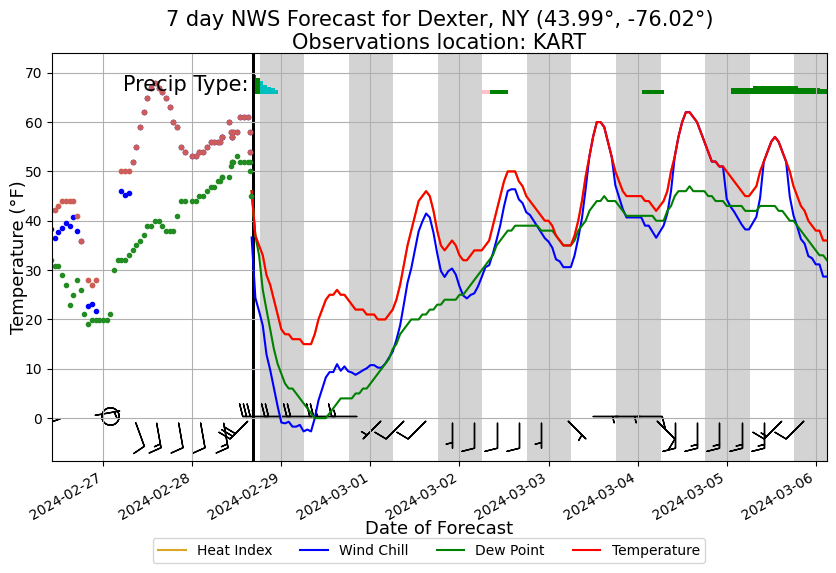

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the historical and forecasted temperatures, dew points, and heat indexes onto the graph.
# Forecasted:
markerStyle = "."
ax.plot(newTimestampFore, listOfHeatIndexFore, color='goldenrod', label="Heat Index")
ax.plot(newTimestampFore, listOfWindChillFore, color='blue', label="Wind Chill")
ax.plot(newTimestampFore, listOfDewsForecast, color='green', label="Dew Point")
ax.plot(newTimestampFore, listOfTempsForecast, color='red', label="Temperature")
# Historical:
ax.plot(newTimestampHist, listOfHeatIndexHist, color='goldenrod', marker=markerStyle, linewidth=0)
ax.plot(newTimestampHist, listOfWindChillHist, color='blue', marker=markerStyle, linewidth=0)
ax.plot(newTimestampHist, listOfDewsHist, color='forestgreen', marker=markerStyle, linewidth=0)
ax.plot(newTimestampHist, listOfTempsHist, color='indianred', marker=markerStyle, linewidth=0)

# The bounds of the plot are set as 2 days before now and the ending timestamp, and the upper and lower temp bounds.
# The lower and upper bounds are the temperature mins and maxs, with a constant offset.
plt.axis([dateOffset - 2, newTimestampFore[-1], tempsLowerBound, tempsUpperBound])

# Adjustable sizing for the size and location of the precip bar at the top of the chart.
# Also determines the size of the wind barbs. 
# This keeps everything consistent between cities with different amounts of daily variation.
axisHeight = ax.get_ylim()[1] - ax.get_ylim()[0]
barbPlacement = axisHeight / 9
pTypeSize = axisHeight / 18
pTypePlacement = axisHeight / 10
pTextPlacement = axisHeight / 13

# Set the length of the wind barb.
barbLength = 6

# This draws the boxes for nighttime on the forecasted section of the plot.
# Whether or not it is considered night is not available from the station observations.
count1 = 0
for i in dataForecastPeriods:
    # The rectangle does not accept a datetime as a coordinate, so it has to be converted.
    # dateOffset is the initial offset, in days since 1970. The current index has to be divided by 24 since it represents hours.
    # The final addition of 6/24 accounts for the shift in time zones. Assumes Central.
    dateOffsetRect = dateOffset + (count1 / 24) + tzOffset
    
    # Draws dark boxes on the plot hour by hour to signify nighttime.
    if(listOfNights[count1] == False):
        rect = patches.Rectangle((dateOffsetRect, -100), (1/24), 300, facecolor='lightgray')
        ax.add_patch(rect)

    # Adds rectangles to chart showing if precipitation is falling during the period and which type if so.
    # Sets the height of the precipitation box to the chance of precipitation.
    rectPrecip = patches.Rectangle((dateOffsetRect, tempsUpperBound-pTypePlacement), (1/24), pTypeSize * listOfPoPsForecast[count1], 
                                   facecolor=str(listOfPrecip[count1]))
    ax.add_patch(rectPrecip)
    
    count1 += 1

# This adds a line to the plot starting at the current time to show where the transition is from obs to forecast.
rectCurrent = patches.Rectangle((dateOffset + tzOffset, -100), (1/36), 300, facecolor='black')
ax.add_patch(rectCurrent)

# The wind barbs need to be graphed after the night boxes, otherwise they tend to get covered up.
# This is the number of hours between wind barbs.
hoursBetweenWind = 6
# This specifically plots every sixth wind barb that is forecasted.
count2 = 0
for j in dataForecastPeriods:
    # Plots a wind barb every 6 units, which is equivalent to every 6 hours.
    if(count2 % hoursBetweenWind == 0):
        stationplot = StationPlot(ax, newTimestampFore[count2], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
        stationplot.plot_barb(listOfWindXandYFore[count2][0], listOfWindXandYFore[count2][1])
        
    count2 += 1

# This section plots the historical wind data for the last few days.
# The timestamp is initialized to allow comparison. This allows the program to only plot the wind barbs every six hours.
# This is needed since stations do not observe at the same intervals, meaning the barbs would otherwise be closer
# or farther apart, depending on the station.
timestampStored = newTimestampHist[0]
count3 = 0
for k in listOfWindsHist:
    # If the difference in time since the last plotted barb is greater than six hours (21,600 seconds), plot a wind barb.
    if((timestampStored - newTimestampHist[count3]).total_seconds() >= hoursBetweenWind * 3600):
        stationplot = StationPlot(ax, newTimestampHist[count3], tempsLowerBound+barbPlacement, clip_on=True, length=barbLength)
        stationplot.plot_barb(listOfWindXandYHist[count3][0], listOfWindXandYHist[count3][1])

        # Reset the timestamp for comparison.
        timestampStored = newTimestampHist[count3]

    count3 += 1

# Set the text sizing. Used for the title and axis sizes.
title_kwargs = dict(ha='center', va='center', fontsize=15)
axis_kwargs = dict(ha='center', va='center', fontsize=13)

# Set the title and axes labels.
ax.set_title("7 day NWS Forecast for " + cityName + ", " + stateAbbr + " (" + str(lat) + "°, " + str(lon) +"°)" + \
             "\nObservations location: " + stationID, **title_kwargs)
ax.set_xlabel("Date of Forecast", **axis_kwargs)
ax.set_ylabel("Temperature (°F)", **axis_kwargs)

# This places the PType text on the graphic in the right place at the right size.
plt.text(float(dateOffset)-(12/24), tempsUpperBound-pTextPlacement, 'Precip Type:', **title_kwargs)

# Enable the grid on the plot.
ax.grid(True)

# Automatically format the dates to make them look much nicer.
fig.autofmt_xdate()

# Add a legend to the plot to make it clear what each product is.
leg = ax.legend(loc=(0.13, -0.25), ncol=4)

# Show the plot.
plt.show()

In [24]:
len(globals())

146